## Decision Boundary

Let' use iris dataset to illustrate logistic regression. This is a famous dataset that contains the sepal and petal length and width of 150 iris flowers of three different species: Iris setosa, Iris versicolor, and Iris virginica

Let’s try to build a classifier to detect the Iris virginica type based only on the petal
width feature.

In [1]:
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)
list(iris)

['data',
 'target',
 'frame',
 'target_names',
 'DESCR',
 'feature_names',
 'filename',
 'data_module']

In [2]:
#The first 3 entries of the data 

iris.data.head(3) 

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2


In [3]:
# The target names

iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

### Now let us split the data and train a logistic regression model on the training set

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# The feature matrix X, containing only the data 'Petal Width (in cm)' of flowers
X = iris.data[["petal width (cm)"]].values 

# The target vector y, turns integer labels into species names, then make boolean: True if virginica, else False
y = iris.target_names[iris.target] == 'virginica'

# Split the dataset into 75% train / 25% test (by default)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Create an untrained Logistic Regression model and train it with the training data
log_reg = LogisticRegression(random_state=42) 
log_reg.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


The model now learns weight w and bias b so sigmoid(wx+b) fits the data.

Let’s now look at the model’s estimated probabilities for flowers with petal widths varying
from 0 cm to 3 cm

In [5]:
import numpy as np
X_new = np.linspace(0, 3, 1000).reshape(-1, 1)         # produces 1000 evenly spaced values starting exactly at 0 and ending exactly at 3, with equal gap
y_proba = log_reg.predict_proba(X_new)                 # predict probabilities for each width; shape (1000, 2): col0=P(not virginica), col1=P(virginica)

# To find the tipping point (smallest width where P(virginica) first reaches 0.5)
decision_boundary = X_new[y_proba[:, 1] >= 0.5][0, 0]  

**y_proba[:, 1] >=0.5** $\rightarrow$ y_proba has shape (1000, 2): one row per width, column 0 is P(not virginica), column 1 is P(virginica).
                       Then we compare that whole array against the threshold 0.5. It goes element by element, asking the question "is this value ≥ 0.5?" of each entry independently, and collects the 1000 yes/no answers into a new array. This is called **Boolean Mask**.
                       
**X_new[ mask ]** $\rightarrow$ when you index an array with a boolean mask of matching length, NumPy keeps only the rows where the mask is True and discards every row where it's False. It acts as a filter, and is known as **Boolean Indexing**.

**[0,0]** $\rightarrow$ Grabs the single boundary value. The filtered array is sorted ascending, so its first element is the smallest width that achieved P ≥ 0.5. The first 0 means "row 0," and the second 0 means "column 0".

### Plotting

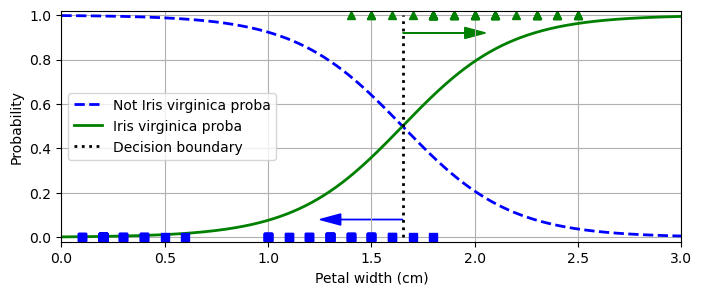

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 3)) # create a new canvas, 8 inches wide × 3 tall
 
plt.plot(X_new, y_proba[:, 0], "b--", linewidth=2, label="Not Iris virginica proba")                    # Plot P(not virginica) as a blue dashed line
plt.plot(X_new, y_proba[:, 1], "g-", linewidth=2, label="Iris virginica proba")                         # Plot P(virginica) as a green solid line

# Let's mark the boundary on the petal-width axis where the model flips its decision. 
# Everything to the left of 1.6 cm, the model calls "not virginica"; everything to the right, it calls "virginica."
plt.plot([decision_boundary, decision_boundary], [0, 1], "k:", linewidth=2, label="Decision boundary")  

plt.arrow(x=decision_boundary, y=0.08, dx=-0.3, dy=0, head_width=0.05, head_length=0.1, fc="b", ec="b")
plt.arrow(x=decision_boundary, y=0.92, dx=0.3, dy=0, head_width=0.05, head_length=0.1, fc="g", ec="g")
plt.plot(X_train[y_train == 0], y_train[y_train == 0], "bs")
plt.plot(X_train[y_train == 1], y_train[y_train == 1], "g^")
plt.xlabel("Petal width (cm)")
plt.ylabel("Probability")
plt.legend(loc="center left")
plt.axis([0, 3, -0.02, 1.02])
plt.grid()

plt.show()